In [1]:
# data processing
import pandas as pd
import numpy as np
from collections import Counter
import imblearn
from pylab import *
%matplotlib inline
import rasterio
from classification_aux import inpsectiontocsv
import os
import multiprocessing as mp
import rasterio as rio
import pickle as pkl

# modelling
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [2]:
data_dir = '/network/scratch/m/matthew.fortier/shared/lichen/raw'
test_sites = ['CG1-8B', 'F3-20B', 'CS-103A', 'ZF20-11A'] # Don't train on these
chicken_columns = [f'chicken_{i}' for i in range(1024)]
non_predictive_columns = ['x_pos', 'y_pos', 'site', 'class_certainty'] # These are removed before training

In [4]:
# Custom train-test-split function
def split_by_sites(df, sites):
    site_indices = df['site'].isin(sites)

    feature_columns = list(df.columns)
    feature_columns.remove('veg_class')

    X = df[feature_columns]
    y = df['veg_class']
    X_train = X[~site_indices].reset_index(drop=True)
    X_test = X[site_indices].reset_index(drop=True)
    y_train = y[~site_indices].reset_index(drop=True)
    y_test = y[site_indices].reset_index(drop=True)

    return X_train, X_test, y_train, y_test

In [5]:
# all features in 'columns' argument will be moved to df2
def split_by_columns(df, columns):
    df2 = df[columns]
    df1 = df.drop(columns, axis=1)
    return df1, df2

In [6]:
def run_experiment(X_train, X_test, y_train, y_test, extra_metrics=False):
    # remove irrelevant columns
    X_train = X_train.drop(columns=non_predictive_columns)
    X_test = X_test.drop(columns=non_predictive_columns)

    # -------------------------------
    # oversample w synthetic minority oversampling to balance classes
    under = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = under.fit_resample(X_train, y_train)

    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    clf=RandomForestClassifier(n_estimators=500, max_depth=10, n_jobs=12)
    clf.fit(X_res.values, y_res.values)

    # -----------------------------------------------------------------------------------------------------------
    # Prediction
    preds = clf.predict(X_test.values)

    print(f'  Train accuracy: {clf.score(X_res, y_res)}')
    print(f'  Test accuracy: {clf.score(X_test, y_test)}')

    if extra_metrics:
        # -----------------------------------------------------------------------------------------------------------
        # Inspect performance parameters: training and testing scores, confusion matrix, and feature importanceax1 = plt.figure(figsize=(5,5)).add_subplot(111)

        cf_matrix = confusion_matrix(y_test, preds,  labels = clf.classes_)
        disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=clf.classes_)
        disp.plot()
        plt.title('Confusion Matrix')

        feature_importance = pd.DataFrame(clf.feature_importances_, index=X_res.columns).sort_values(by=0, ascending=False)
        print(feature_importance)

    return clf, preds

In [8]:
df = pd.read_csv("dataset_large_vit_transformed.csv")

In [9]:
# For now, remove the chicken columns
dfn, _ = split_by_columns(df, chicken_columns)

In [10]:
# Use certainty 1 and 2
dfn_reduced = dfn[dfn['class_certainty'] <= 2]

/home/mila/m/matthew.fortier/.conda/envs/scratch/lib/python3.9/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


  Train accuracy: 0.7520785460622519
  Test accuracy: 0.7143701951507984


/home/mila/m/matthew.fortier/.conda/envs/scratch/lib/python3.9/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


                  0
chm        0.126093
bc         0.067437
GLI        0.067310
rc/gc      0.064568
rc+gc      0.063638
Ikaw       0.056496
rc         0.055947
ExG        0.052770
MGRVI      0.052011
gc         0.051447
ExB        0.050280
z_score_Y  0.041103
ExGmExR    0.040860
z_score_L  0.040178
G          0.036140
B          0.030536
L          0.029668
Y          0.028945
R          0.023214
ExR        0.021360


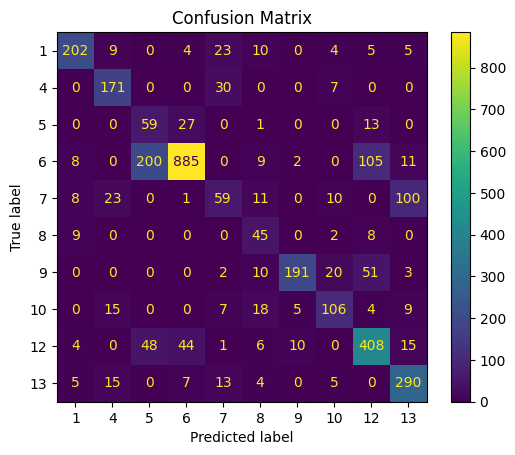

In [11]:
# Random forest without texture data
X_train, X_test, y_train, y_test = split_by_sites(dfn_reduced, test_sites)
model, _ = run_experiment(X_train, X_test, y_train, y_test, extra_metrics=True)

In [ ]:
#========================
# Qualitative Evaluation
#========================

In [ ]:
site = 'CS-103A'
run_name = f'{site}_01'

# location of raw lichen data
data_dir = '/network/scratch/m/matthew.fortier/shared/lichen/raw'

# place where we stored chunked feature data
run_dir = f'/network/scratch/m/matthew.fortier/runs/{run_name}'

In [12]:
# Do some memory cleanup to make room for the beeg files
del df
del dfn
del dfn_reduced

In [14]:
site = 'CS-103A'
blocks = 4
chm = 3 # hard coded index of chm data

rgb_file = os.path.join(data_dir, site, f'{site}_hp_transparent_mosaic_group1.tif')

with rio.open(rgb_file) as f:
    meta = f.meta

curr_y = 0
curr_x = 0
h = 0
w = 0

output = np.zeros((meta['height'], meta['width']))
for y in range(blocks):
    for x in range(blocks):
        print(f'Processing block {y}-{x}')
        
        file_path = os.path.join(run_dir, 'composite', f'chunk_{y}_{x}.pkl')
        if not os.path.isfile(file_path):
            continue
    
        with open(file_path, "rb") as file:
            # Use pickle.load() to read the dictionary from the file
            block = pkl.load(file)
        h = block.shape[1]
        w = block.shape[2]
        
        block_output = np.zeros((h, w))
        
        # get coordinates of relevant pixels
        py, px = np.where(block[chm] >= 0)
        if len(py) > 0:
            features = block[:, py, px].T
            block_output[py, px] = model.predict(features)
            output[curr_y:curr_y+h, curr_x:curr_x+w] = block_output
            del features
        
        curr_x += w
        del block, block_output, py, px

    curr_x = 0
    curr_y += h
    

Processing block 0-0
Processing block 0-1
Processing block 0-2
Processing block 0-3
Processing block 1-0
Processing block 1-1
Processing block 1-2
Processing block 1-3
Processing block 2-0
Processing block 2-1
Processing block 2-2
Processing block 2-3
Processing block 3-0
Processing block 3-1
Processing block 3-2
Processing block 3-3


In [16]:
out_file = '/network/scratch/m/matthew.fortier/CS-103A-classified.tif'

meta.update(count=1)

# Write a new .tif file using the metadata from the original file
with rasterio.open(out_file, 'w', **meta) as dst:
    dst.write(output, 1)

In [ ]:
#==========================================================
# Below here is the experimental work with texture features 
#==========================================================

In [ ]:
# Random forest with *all* texture data (1024 features for large dino)
X_train, X_test, y_train, y_test = split_by_sites(df[df['class_certainty'] <= 2], test_sites)
y_pred = run_experiment(X_train, X_test, y_train, y_test)

In [ ]:
# Random forest with 16 texture features
num_features = 16
df_base, df_chicken = split_by_columns(df, chicken_columns)
df_chicken = df_chicken.iloc[:, :num_features]
df_16 = pd.concat([df_base, df_chicken], axis=1)

X_train, X_test, y_train, y_test = split_by_sites(df_16[df_16['class_certainty'] <= 2], test_sites)
run_experiment(X_train, X_test, y_train, y_test)

In [ ]:
# Random forest with 32 texture features
num_features = 32
df_base, df_chicken = split_by_columns(df, chicken_columns)
df_chicken = df_chicken.iloc[:, :num_features]
df_32 = pd.concat([df_base, df_chicken], axis=1)

X_train, X_test, y_train, y_test = split_by_sites(df_32[df_32['class_certainty'] <= 2], test_sites)
run_experiment(X_train, X_test, y_train, y_test)

In [ ]:
# New dataset with embedding of texture features
num_features = 32

# We're going to split the train data into train/val, so we can train an encoder on texture features
X_train, X_test, y_train, y_test = split_by_sites(df, test_sites)

# Peel off the texture features in the train set so we can train an encoder
df_main_tr, df_chicken_tr = split_by_columns(X_train, chicken_columns)
df_main_te, df_chicken_te = split_by_columns(X_test, chicken_columns)

softmax_to_class = {1:0, 4:1, 5:2, 6:3, 7:4, 8:5, 9:6, 10:7, 12:8, 13:9}

X_train_chicken = torch.tensor(df_chicken_tr.values, dtype=torch.float)
X_test_chicken  = torch.tensor(df_chicken_te.values, dtype=torch.float)
y_train_chicken = torch.tensor([softmax_to_class[y] for y in y_train.values])
y_test_chicken  = torch.tensor([softmax_to_class[y] for y in y_test.values])

In [ ]:
class FFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.5):
        super(FFNN, self).__init__()
        self.dropout = nn.Dropout(p=dropout_prob)
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.constant_(self.fc2.bias, 0)

    def forward(self, x):
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def encode(self, x):
        return self.fc1(x)

In [ ]:
# NN training for dino feature downprojection
num_epochs = 2001

network = FFNN(len(chicken_columns), num_features, 10)
loss_fn = nn.CrossEntropyLoss()
opt = optim.AdamW(network.parameters(), lr=0.000001, betas=(0.9, 0.999))

train_dataset = TensorDataset(X_train_chicken, y_train_chicken)
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataset = TensorDataset(X_test_chicken, y_test_chicken)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True)

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

# Iterate over the dataloader for multiple epochs
for epoch in range(num_epochs):
    train_loss = train_correct = train_total = 0
    test_loss  = test_correct  = test_total  = 0
    
    network.train()
    for inputs, targets in train_dataloader:
        y_pred = network(inputs) 
        loss = loss_fn(y_pred, targets)
        train_loss += loss.detach().numpy()
        
        _, predicted = torch.max(y_pred.data, 1)
        train_total += targets.size(0)
        train_correct += (predicted == targets).sum().item()

        opt.zero_grad()
        loss.backward()
        opt.step()
    train_losses.append(train_loss / len(train_dataloader))
    train_accuracies.append(100 * train_correct / train_total)
    

    network.eval()
    with torch.no_grad():
        for inputs, targets in test_dataloader:
            y_pred = network(inputs)
            loss = loss_fn(y_pred, targets).item()
            test_loss += loss

            _, predicted = torch.max(y_pred.data, 1)
            test_total += targets.size(0)
            test_correct += (predicted == targets).sum().item()

    test_losses.append(test_loss / len(test_dataloader))
    test_accuracies.append(100 * test_correct / test_total)
    
    if epoch % 200== 0:
        print(f'Finished epoch {epoch}')
        print(f'    Training loss: {train_losses[-1]:.4f}')
        print(f'    Training accuracy: {train_accuracies[-1]:.2f}%')
        print(f'    Test loss: {test_losses[-1]:.4f}')
        print(f'    Test accuracy: {test_accuracies[-1]:.2f}%')


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot train and test accuracies
axs[0].plot(range(num_epochs), train_accuracies, label='Train Accuracy')
axs[0].plot(range(num_epochs), test_accuracies, label='Test Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Train and Test Accuracies')
axs[0].legend()

# Plot train and test losses
axs[1].plot(range(num_epochs), train_losses, label='Train Loss')
axs[1].plot(range(num_epochs), test_losses, label='Test Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Train and Test Losses')
axs[1].legend()

# Adjust spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
y_pred = network(X_test_chicken)
y_pred = torch.max(y_pred.data, 1)[1].detach().numpy()
y_targ = y_test_chicken.detach().numpy()

In [ ]:
conf_matrix = confusion_matrix(y_targ, y_pred)
ConfusionMatrixDisplay(conf_matrix).plot()

In [ ]:
pd.DataFrame(y_pred).value_counts()

In [ ]:
df_chicken_tr_reduced = pd.DataFrame(network.encode(torch.tensor(df_chicken_tr.values, dtype=torch.float)).detach().numpy(), columns=[f'chicken_{i}' for i in range(num_features)])
df_chicken_te_reduced = pd.DataFrame(network.encode(torch.tensor(df_chicken_te.values, dtype=torch.float)).detach().numpy(), columns=[f'chicken_{i}' for i in range(num_features)])

# Concat the reduced texture features back onto the rgb features
X_train = pd.concat([df_main_tr, df_chicken_tr_reduced], axis=1)
X_test = pd.concat([df_main_te, df_chicken_te_reduced], axis=1)

run_experiment(X_train, X_test, y_train, y_test)

In [ ]:
len(y_train)

In [ ]:
# ==========================================================================================
# Calculate permutation matrix and save figure
# ==========================================================================================
perm_importance = permutation_importance(clf, X_test, y_test)
sorted_idx = perm_importance.importances_mean.argsort()
print(sorted_idx)
importances = pd.DataFrame(
    perm_importance.importances[sorted_idx].T,
    columns=X.columns[sorted_idx],
)

ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
figname = f'perm_{runname}.png'
savefig(savepath+figname, dpi=150, bbox_inches='tight')

In [ ]:
# ==========================================================================================
# save classifier in object 
# ==========================================================================================

# Add columns attribute to classifier. 
# This is important information as .tifs that should be classified need to have the same features and in the same order
clf.col_names=X.columns

# -----------------------------------------------------------------------------------------------------------
# !! careful this can make objects of several GB size
outpath = 'data/clfs/'
outfile = 'clf_%s_TEST.pkl' % run
joblib.dump(clf, outpath+outfile) 

In [ ]:
'''
dfo = pd.read_csv("prior_dataset_transformed.csv") # Maria's original dataset



# Correct wrong chm values in new dataset, using old dataset as a reference.
# This is a temporary measure while I figure out a more efficient way to get accurate chm values
# from the low resolution raster
df_reduced = df[df['site'].isin(dfo['site'].unique())]
dfm = pd.concat([dfo,df_reduced]).drop_duplicates(keep=False, subset=['R', 'G', 'B', 'chm', 'site']).sort_values(['site', 'R', 'G', 'B'])[['site', 'veg_class', 'R', 'G', 'B', 'chm']]
print(dfm)
print('cleaning chm values')
#dfm.to_csv('test1.csv')
for i, (index, cur_row) in enumerate(dfm.iterrows()):
    if i == 0:
        continue
    prv_row = dfm.iloc[i-1]
    if prev_row['site'] == curr_row['site'] and \
       prev_row['R'] == curr_row['R'] and \
       prev_row['G'] == curr_row['G'] and \
       prev_row['B'] == curr_row['B'] and \
       type(prev_row['veg_class']) == str: # this ensures we're copying from Maria's data to ours
        df.loc[index, 'chm'] = prv_row['chm']

df_reduced = df[df['site'].isin(dfo['site'].unique())]
dfm = pd.concat([dfo,df_reduced]).drop_duplicates(keep=False, subset=['R', 'G', 'B', 'chm', 'site']).sort_values(['site', 'R', 'G', 'B'])[['site', 'veg_class', 'R', 'G', 'B', 'chm']]

#dfm.to_csv('test2.csv')
print(dfm)
'''